Download data
!mkdir -p data/GSE123813

!wget -q -P data/GSE123813 \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813_scc_metadata.txt.gz

!wget -q -P data/GSE123813 \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813_scc_scRNA_counts.txt.gz

!wget -q -P data/GSE123813 \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE123nnn/GSE123813/suppl/GSE123813_scc_tcr.txt.gz



In [14]:
# import packages
import warnings
warnings.filterwarnings("ignore")

#import decoupler as dc 
import pandas as pd
import scanpy as sc
import numpy as np

In [15]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch
from rich import print
#from scib_metrics.benchmark import Benchmarker

In [16]:
# probably add scirpy in here?
#tcr_info = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_tcr.txt.gz", sep="\t", index_col=0)

In [17]:
DATA_DIR = "/home/roger/protocol/cancer-pseudotime-grn-workflow/scripts/data/GSE123813"

metadata = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_metadata.txt.gz", sep="\t")
counts = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_scRNA_counts.txt.gz", sep="\t", index_col=0)

# create adata object
adata = sc.AnnData(counts.T)
adata.obs = metadata.set_index(metadata.columns[0]).loc[adata.obs_names]

In [18]:
adata.obs['celltype'] = adata.obs['cluster']

In [19]:
# Classical preprocessing using scanpy

# Mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# Hemoglobin genes (excluding pseudogenes HB(P))
adata.var["hb"] = adata.var_names.str.startswith("HB") & ~adata.var_names.str.contains("HBP")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True
)


In [20]:
# Remove non-useful cells.
adata = adata[
    (adata.obs["n_genes_by_counts"] > 1000) &
    (adata.obs["n_genes_by_counts"] < 4000) &
    (adata.obs["pct_counts_mt"] < 8) &
    (adata.obs["total_counts"] < 12000)
].copy()

In [21]:
adata.obs['celltype'].unique()

array(['CD8_naive', 'Th17', 'Treg', 'CD8_mem', 'CD8_eff', 'CD8_ex',
       'CD8_act', 'Naive', 'Tfh', 'CD8_ex_act'], dtype=object)

In [22]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000) #, subset=True)
#ad = ad[:, ad.var["highly_variable"]].copy()
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=16)
sc.pp.neighbors(adata, n_pcs=16)
sc.tl.leiden(adata, resolution=0.7)
sc.tl.umap(adata) # we can change min_dist?!?!


In [23]:
adata.write("/home/roger/data_itx/adata_all.h5ad")

In [29]:
adata.obs['celltype_treatment'] = (adata.obs['celltype'].astype(str) + '_' + adata.obs['treatment'].astype(str)).astype('category')

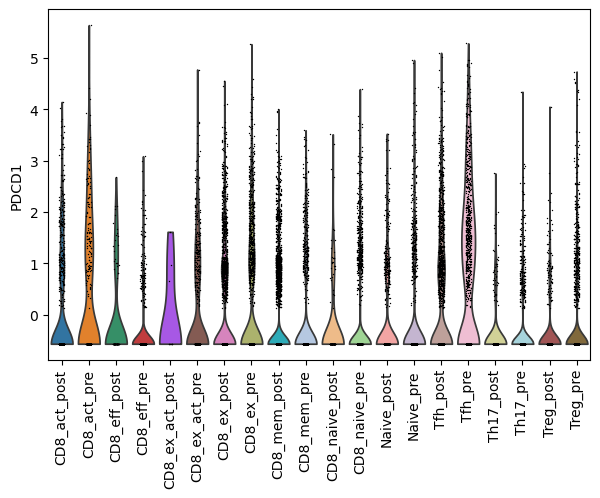

In [36]:
sc.pl.violin(adata, keys=["PDCD1"], groupby="celltype_treatment", rotation=90, save="violin.png")

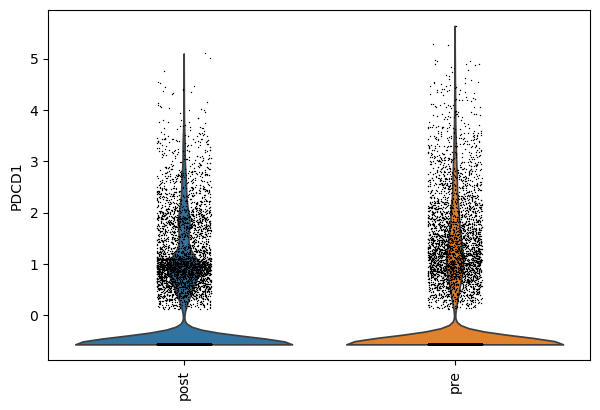

In [32]:
sc.pl.violin(adata, keys=["PDCD1"], groupby="treatment", rotation=90)

https://docs.scvi-tools.org/en/1.4.1/tutorials/notebooks/scrna/harmonization.html

# incorporate batch correctiona also.
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
model.train()

SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)


This is when we do have cell type annotation
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=adata,
    labels_key="cell_type",
    unlabeled_category="Unknown",
)

scanvi_model.train(max_epochs=20, n_samples_per_label=100)
SCANVI_LATENT_KEY = "X_scANVI"
adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)
sc.pp.neighbors(adata, use_rep=SCANVI_LATENT_KEY)


In [10]:
def run_pipeline_correct(adata_subset, label):
    ad = adata_subset.copy()
    ad.layers["counts"] = ad.X.copy()

    sc.pp.normalize_total(ad)
    sc.pp.log1p(ad)
    
    sc.pp.highly_variable_genes(ad, n_top_genes=2000, subset=True)
    #ad = ad[:, ad.var["highly_variable"]].copy()

    # incorporate batch correctiona also.
    scvi.model.SCVI.setup_anndata(ad, layer="counts", batch_key="patient")
    model = scvi.model.SCVI(ad, n_layers=2, n_latent=30, gene_likelihood="nb")
    model.train()

    SCVI_LATENT_KEY = "X_scVI"
    ad.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
    
    sc.pp.neighbors(ad, use_rep=SCVI_LATENT_KEY)
    sc.tl.leiden(ad, resolution=0.7)
    sc.tl.umap(ad) # we can change min_dist?!?!
    
    sc.pl.umap(ad, color=["leiden", "celltype", "patient"], title=label)
    
    return ad

In [11]:
def run_pipeline(adata_subset, label):
    ad = adata_subset.copy()
    
    sc.pp.normalize_total(ad)
    sc.pp.log1p(ad)
    
    sc.pp.highly_variable_genes(ad, n_top_genes=2000, subset=True)
    #ad = ad[:, ad.var["highly_variable"]].copy()
    sc.pp.scale(ad)
    sc.tl.pca(ad, n_comps=16)
    sc.pp.neighbors(ad, n_pcs=16)
    sc.tl.leiden(ad, resolution=0.7)
    sc.tl.umap(ad) # we can change min_dist?!?!
    
    sc.pl.umap(ad, color=["leiden", "celltype", "patient"], title=label)
    
    return ad

In [12]:
# prova com queda a nivell de CD8.

In [13]:
cd8_clusters = ["CD8_ex", "CD8_mem", "CD8_eff", "CD8_naive", "CD8_ex_act", "CD8_act"]
CD8 = adata[adata.obs['celltype'].isin(cd8_clusters)]

In [14]:
label = "prova"

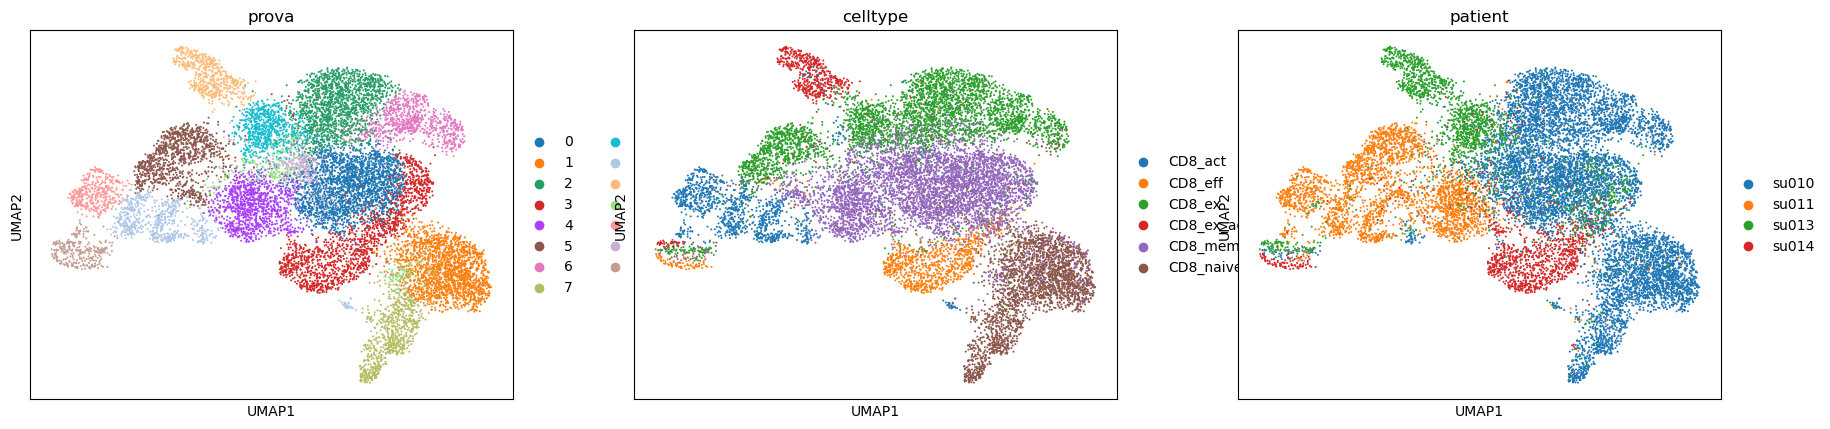

AnnData object with n_obs × n_vars = 14385 × 2000
    obs: 'patient', 'treatment', 'cluster', 'UMAP1', 'UMAP2', 'celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'celltype_colors', 'patient_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [16]:
run_pipeline(CD8, label)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


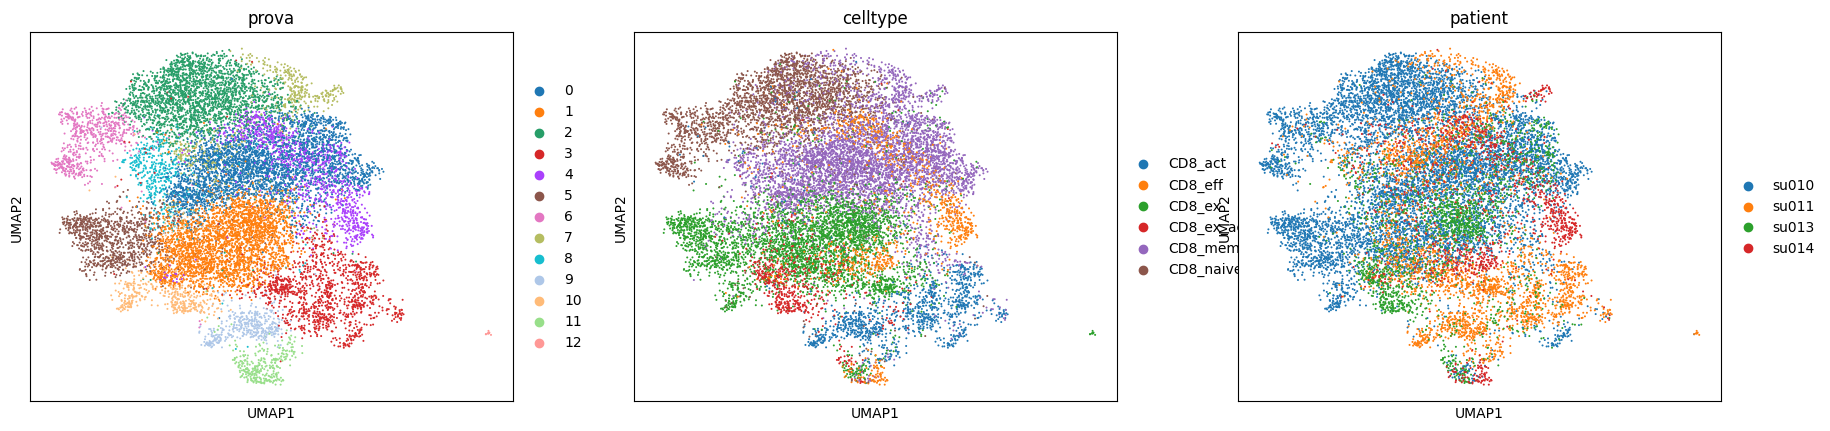

CPU times: user 2h 6min 49s, sys: 14.3 s, total: 2h 7min 3s
Wall time: 18min 35s


AnnData object with n_obs × n_vars = 14385 × 2000
    obs: 'patient', 'treatment', 'cluster', 'UMAP1', 'UMAP2', 'celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'celltype_colors', 'patient_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [34]:
%%time
run_pipeline_correct(CD8, label)

In [36]:
CD8

View of AnnData object with n_obs × n_vars = 14385 × 18347
    obs: 'patient', 'treatment', 'cluster', 'UMAP1', 'UMAP2', 'celltype', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

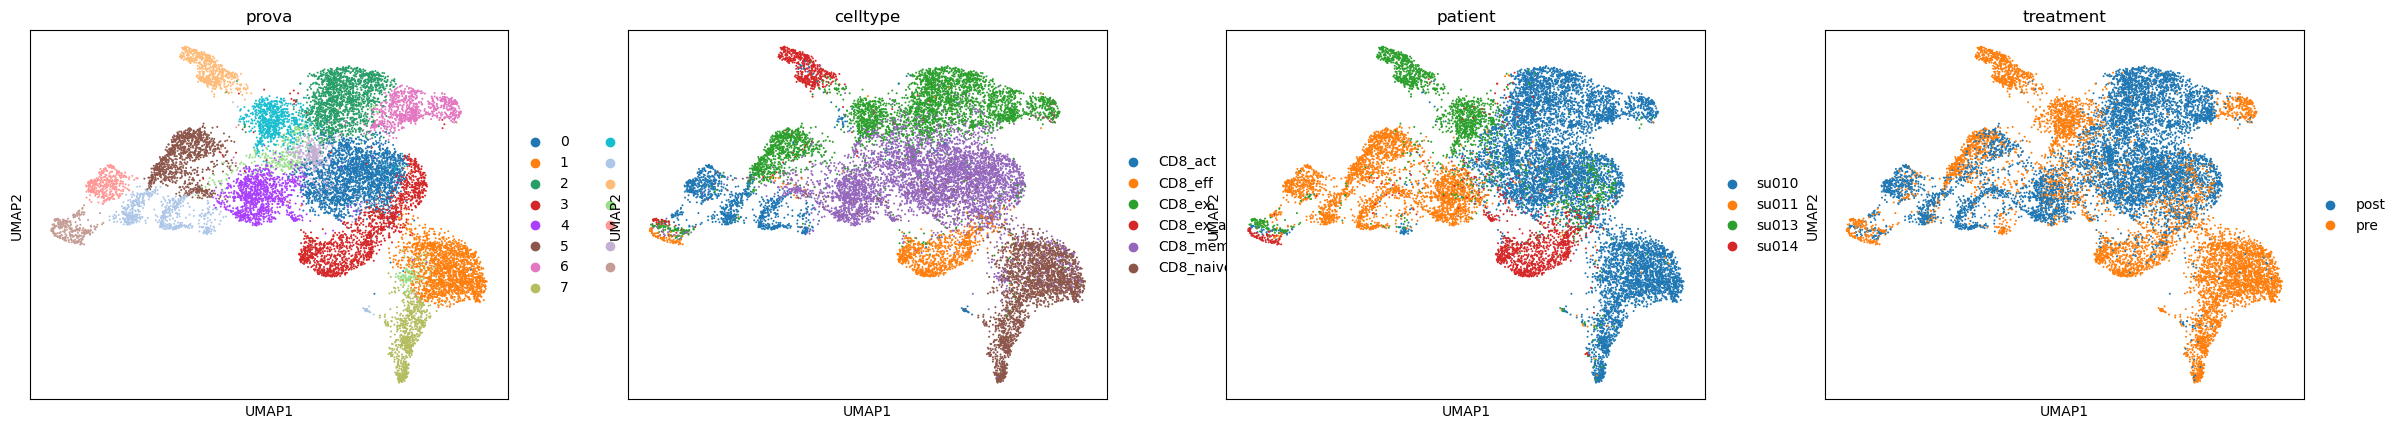

In [17]:
ad = CD8.copy()
ad.layers["counts"] = ad.X.copy()


sc.pp.normalize_total(ad)
sc.pp.log1p(ad)

sc.pp.highly_variable_genes(ad, n_top_genes=2000, subset=True)
#ad = ad[:, ad.var["highly_variable"]].copy()
sc.pp.scale(ad)
sc.tl.pca(ad, n_comps=16)
sc.pp.neighbors(ad, n_pcs=16)
sc.tl.leiden(ad, resolution=0.7)
sc.tl.umap(ad, min_dist=0.3) # we can change min_dist?!?!
sc.pl.umap(ad, color=["leiden", "celltype", "patient", "treatment"], title=label)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


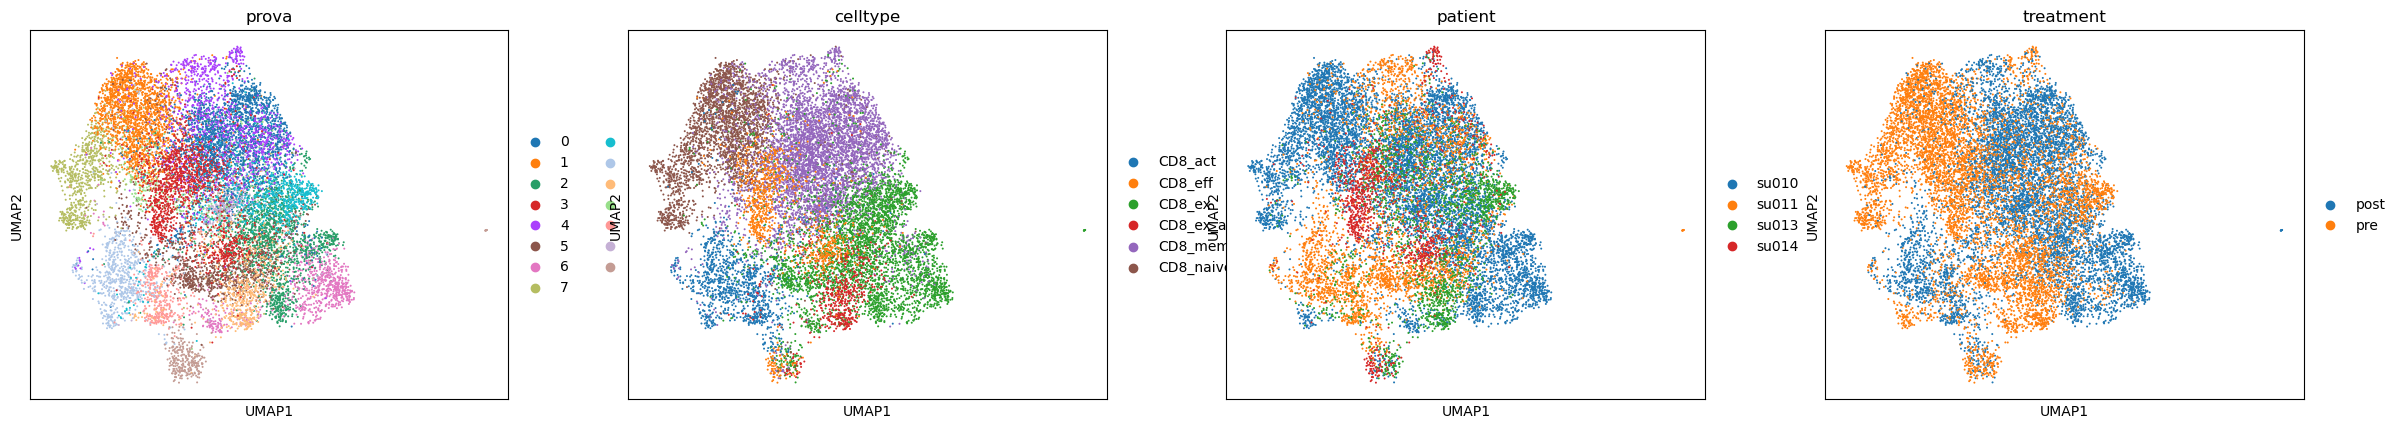

CPU times: user 55min 14s, sys: 2.6 s, total: 55min 17s
Wall time: 9min 35s


In [23]:
%%time
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # make to not see the GPU

scvi.model.SCVI.setup_anndata(ad, layer="counts", batch_key="patient")
model = scvi.model.SCVI(ad, n_layers=2, n_latent=30, gene_likelihood="nb")
model.train(accelerator="cpu", devices=1)

SCVI_LATENT_KEY = "X_scVI"
ad.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

sc.pp.neighbors(ad, use_rep=SCVI_LATENT_KEY)
#sc.tl.leiden(ad, resolution=0.7)
sc.tl.umap(ad) # we can change min_dist?!?!

sc.pl.umap(ad, color=["leiden", "celltype", "patient", "treatment"], title=label)

In [24]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=ad,
    labels_key="celltype",
    unlabeled_category="Unknown",
)

In [25]:
%%time
scanvi_model.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


CPU times: user 5min 9s, sys: 276 ms, total: 5min 9s
Wall time: 51.9 s


In [26]:
SCANVI_LATENT_KEY = "X_scANVI"
ad.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(ad)

In [27]:
sc.pp.neighbors(ad, use_rep=SCANVI_LATENT_KEY)
sc.tl.umap(ad)

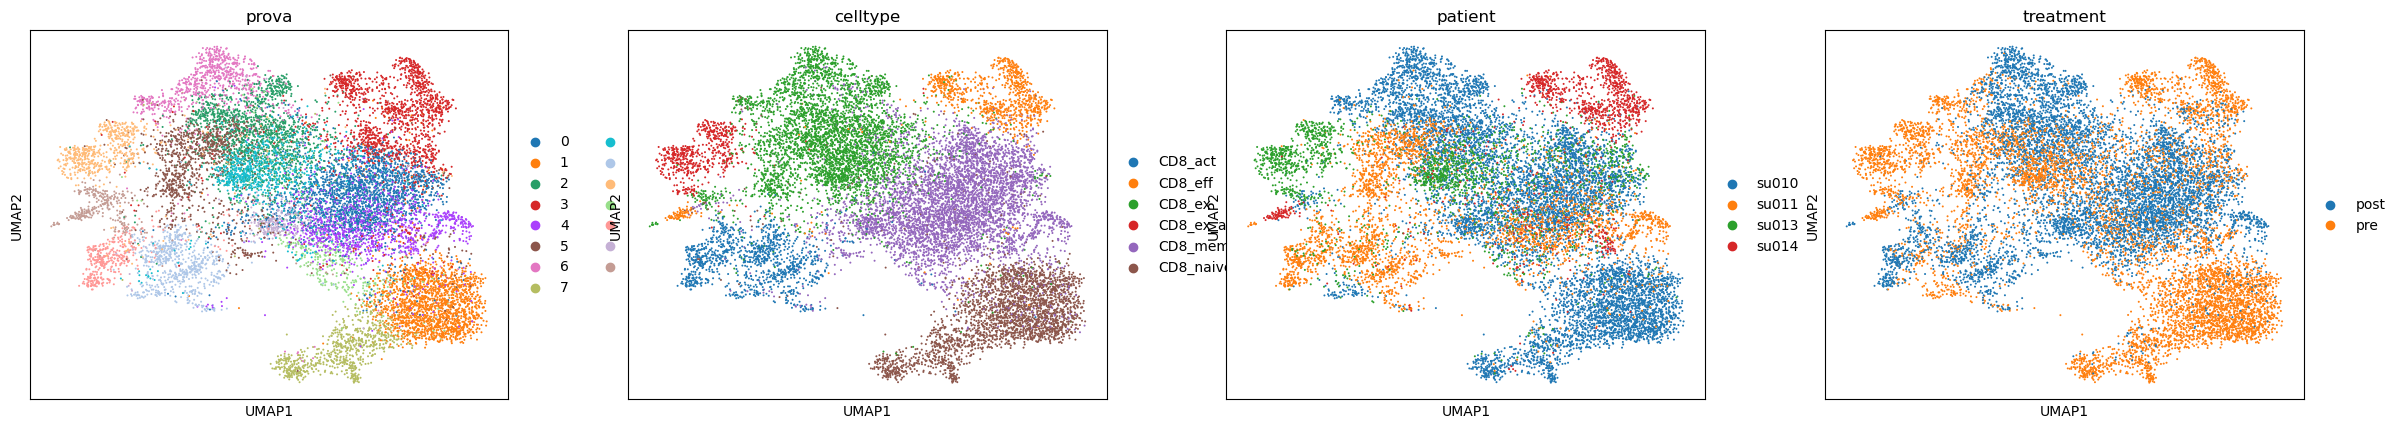

In [28]:
sc.pl.umap(ad, color=["leiden", "celltype", "patient", "treatment"], title=label)

In [29]:
ad.write("adata_cd8_integrated.h5ad")

In [50]:
bm = Benchmarker(
    ad,
    batch_key="patient",
    label_key="celltype",
    embedding_obsm_keys=["X_pca", SCVI_LATENT_KEY, SCANVI_LATENT_KEY],
    n_jobs=-1,
)
bm.benchmark()

Metrics:   0%|                                                | 0/10 [00:00<?, ?it/s, Bio conservation: isolated_labels]WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.

Embeddings:  33%|████████████████████████                                                | 1/3 [01:44<03:29, 104.82s/it]
                                                                                                                        
Embeddings:  67%|████████████████████████████████████████████████▋                        | 2/3 [02:52<01:23, 83.10s/it]
                                                                                                                        
Embeddings: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [03:46<00:00, 75.44s/it]

                                                                                                                        

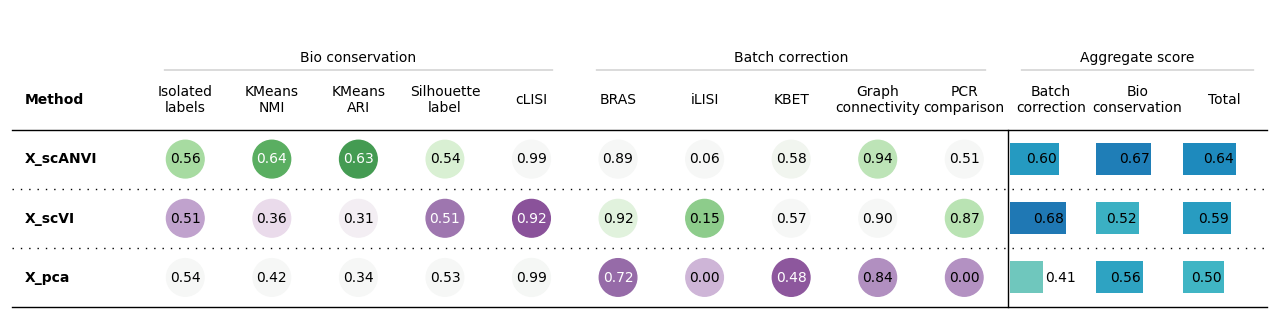

In [51]:
bm.plot_results_table(min_max_scale=False)

In [ ]:
#save adata.


In [ ]:
# should I do a bit of integration based on donor?

... storing 'patient' as categorical
... storing 'treatment' as categorical
... storing 'cluster' as categorical
... storing 'celltype' as categorical


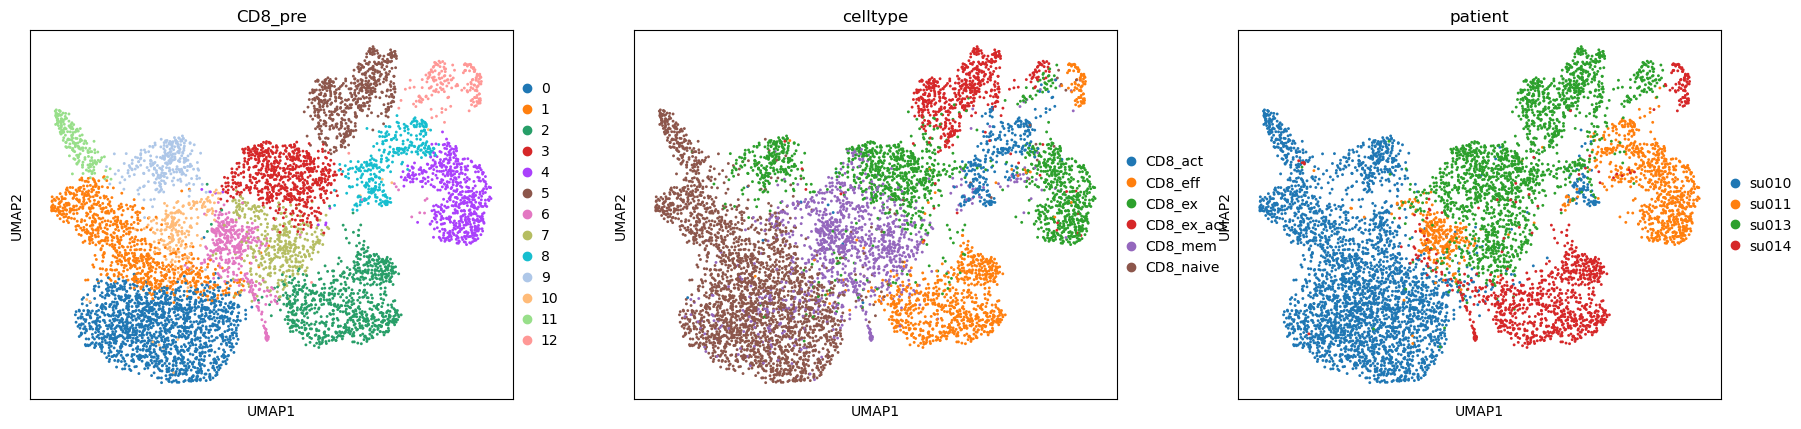

... storing 'patient' as categorical
... storing 'treatment' as categorical
... storing 'cluster' as categorical
... storing 'celltype' as categorical


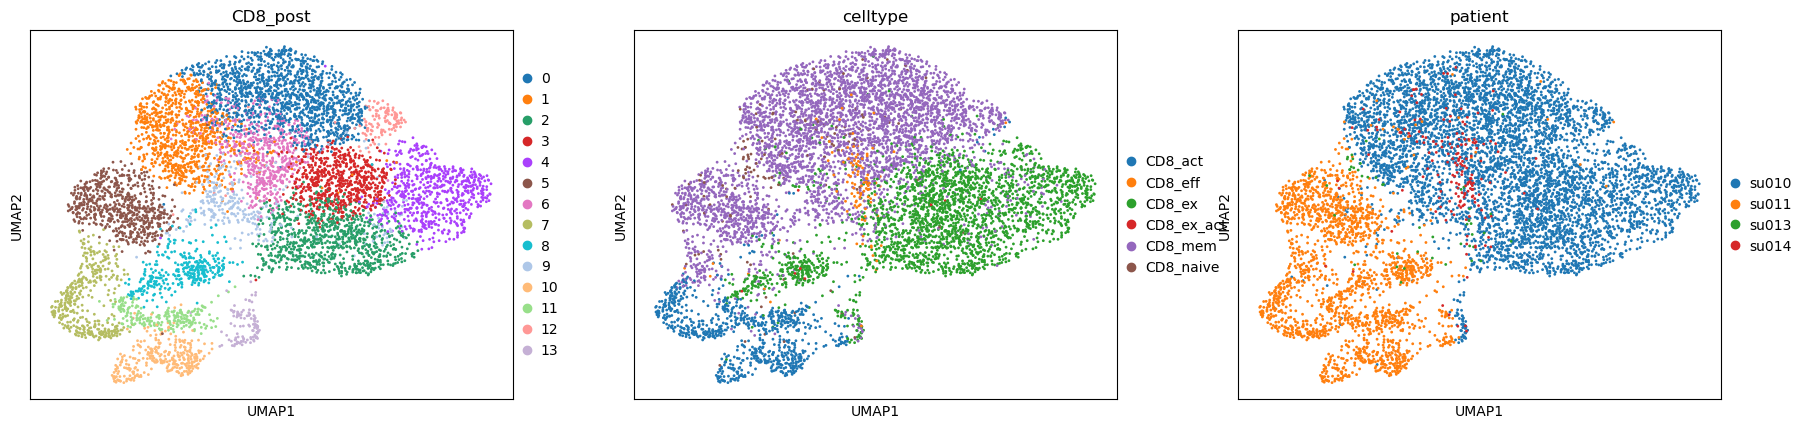

... storing 'patient' as categorical
... storing 'treatment' as categorical
... storing 'cluster' as categorical
... storing 'celltype' as categorical


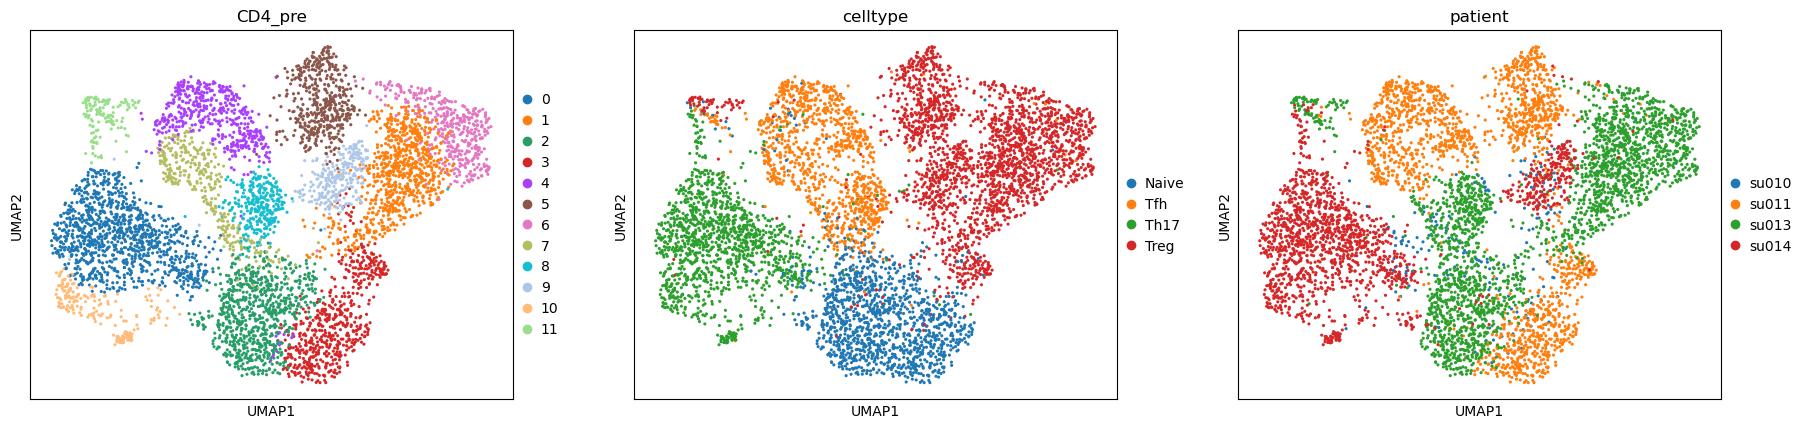

... storing 'patient' as categorical
... storing 'treatment' as categorical
... storing 'cluster' as categorical
... storing 'celltype' as categorical


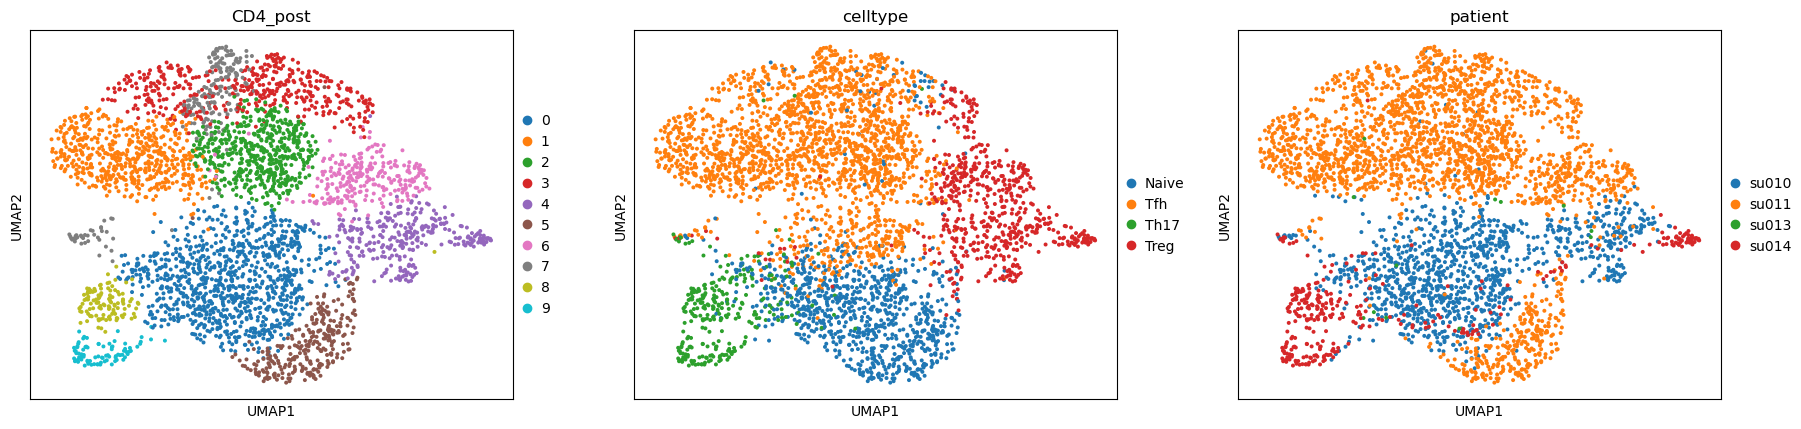

In [24]:
# Define groups
cd8_clusters = ["CD8_ex", "CD8_mem", "CD8_eff", "CD8_naive", "CD8_ex_act", "CD8_act"]
cd4_clusters = ["Treg", "Naive", "Tfh", "Th17"]

groups = {
    "CD8": cd8_clusters,
    "CD4": cd4_clusters
}

treatments = ["pre", "post"]

results = {}

for name, ctype in groups.items():
    
    # Filter once per cell type
    ad_ct = adata[adata.obs["celltype"].isin(ctype)]
    
    for treat in treatments:
        ad_sub = ad_ct[ad_ct.obs["treatment"] == treat]
        
        label = f"{name}_{treat}"
        results[label] = run_pipeline(ad_sub, label)

In [ ]:
for name, ctype in groups.items():
    
    ad_ct = adata[adata.obs["celltype"].isin(ctype)]
    
    label = f"{name}_ALL"
    results[label] = run_pipeline(ad_ct, label)

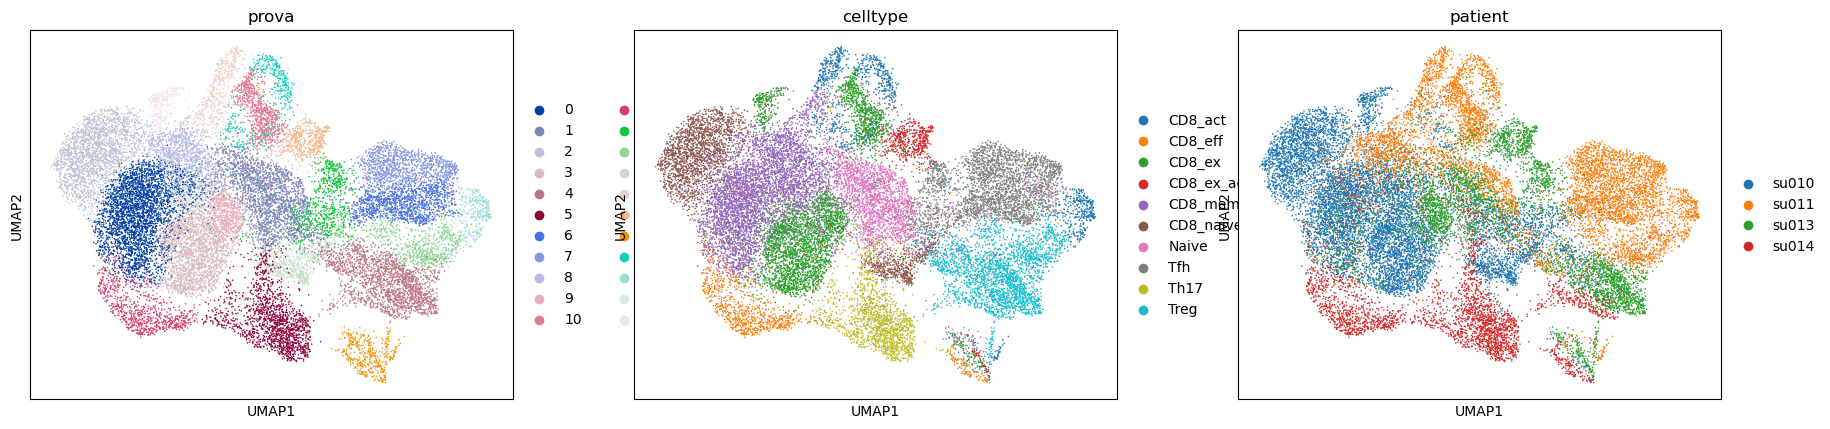

In [42]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

#sc.pp.highly_variable_genes(adata, n_top_genes=2000) #, subset=True)
#ad = ad[:, ad.var["highly_variable"]].copy()
sc.pp.scale(adata)
#sc.tl.pca(adata, n_comps=16)
sc.pp.neighbors(adata, n_pcs=16)
sc.tl.leiden(adata, resolution=1)
sc.tl.umap(adata) # we can change min_dist?!?!

sc.pl.umap(adata, color=["leiden", "celltype", "patient"], title=label)

In [43]:
gold = pd.read_csv("/home/roger/Baixades/DEGs_nkts_vs_T.csv", index_col=0)
names = gold.head(50)['names'].to_list()
sc.tl.score_genes(adata, gene_list=names, score_name="nkt")

KeyError: "None of [Index(['TRBV25-1', 'TRAV10', 'KLRB1', 'DUSP2', 'GZMK', 'KLRG1', 'CEBPD',\n       'CCL5', 'GZMA', 'NCR3', 'CTSW', 'NKG7', 'DUSP1', 'CXCR4', 'LYAR',\n       'SLC4A10', 'CST7', 'IL7R', 'ARL4C', 'ZBTB16', 'PRF1', 'MYBL1',\n       'PHACTR2', 'ZFP36L2', 'NFKBIA', 'ERN1', 'PARP8', 'PLCB1', 'HCST', 'ID2',\n       'CD69', 'ZFP36', 'ALOX5AP', 'MATK', 'IL32', 'HOPX', 'IFNGR1', 'FOS',\n       'SRGN', 'HLA-B', 'MT-ND4L', 'GBP5', 'GPR65', 'HLA-C', 'TNFAIP3',\n       'STAT4', 'XBP1', 'BTG1', 'TGFB1'],\n      dtype='object')] are in the [index]"

In [ ]:
sc.pl.umap(adata, color=['leiden', 'celltype', 'nkt', 'TRAV10', 'TRAV1-2'])

In [ ]:
sc.pl.violin(adata, keys=['nkt', 'TRAV10'], groupby='leiden')